In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde

## Dataset

In [98]:
df = pd.read_csv('data/pre-thin-data.csv')
df.head()

,Row,Tree,pre_DBH,pre_HT,pre_LLC,pre_stem_vol
0,1,1,10.8,69.788672,NaN,19.593049
1,1,2,6.8,62.771152,NaN,7.127531
2,1,3,6.1,60.770923,NaN,5.601351
3,1,4,5.5,58.873375,NaN,4.458079
4,1,5,10.5,69.522875,NaN,18.461945


## Alive/Dead Analysis

In [188]:
df['status'] = df['pre_HT'].apply(lambda x: 'Alive' if pd.notnull(x) and x > 0 else 'Dead')

status_counts = df['status'].value_counts()
status_percent = df['status'].value_counts(normalize=True) * 100

print("Tree status counts:")
print(status_counts)
print("\nTree status percentages:")
print(status_percent.round(2))
df.head(30)

Tree status counts:
status
Alive    3017
Dead      236
Name: count, dtype: int64

Tree status percentages:
status
Alive    92.75
Dead      7.25
Name: proportion, dtype: float64


,Row,Tree,pre_DBH,pre_HT,pre_LLC,pre_stem_vol,status,thin_decision
0,1,1,10.8,69.788672,NaN,19.593049,Alive,Keep
1,1,2,6.8,62.771152,NaN,7.127531,Alive,Keep
2,1,3,6.1,60.770923,NaN,5.601351,Alive,Keep
3,1,4,5.5,58.873375,NaN,4.458079,Alive,Keep
4,1,5,10.5,69.522875,NaN,18.461945,Alive,Keep
5,1,6,8.6,66.858448,NaN,11.988235,Alive,Keep
6,1,7,7.8,65.229632,NaN,9.664689,Alive,Keep
7,1,8,7.9,65.449663,NaN,9.941108,Alive,Keep
8,1,9,9.7,68.607547,NaN,15.583066,Alive,Keep
9,1,10,8.4,67.800000,39.4,11.605334,Alive,Keep


## 3-row thinning

=== Stand Analysis Report ===
Pre-thinning median DBH: 8.9
Pre-thinning mean DBH: 8.98
Pre-thinning total volume (m³): 41146.3
Post-thinning median DBH: 8.9
Post-thinning mean DBH: 8.98
Post-thinning total volume (m³): 27757.68
Volume removed (m³): 13388.63
% volume removed: 32.54
Trees removed: 981
Trees kept: 2036
% trees removed: 32.52
Change in median DBH: 0.0
Change in mean DBH: -0.0


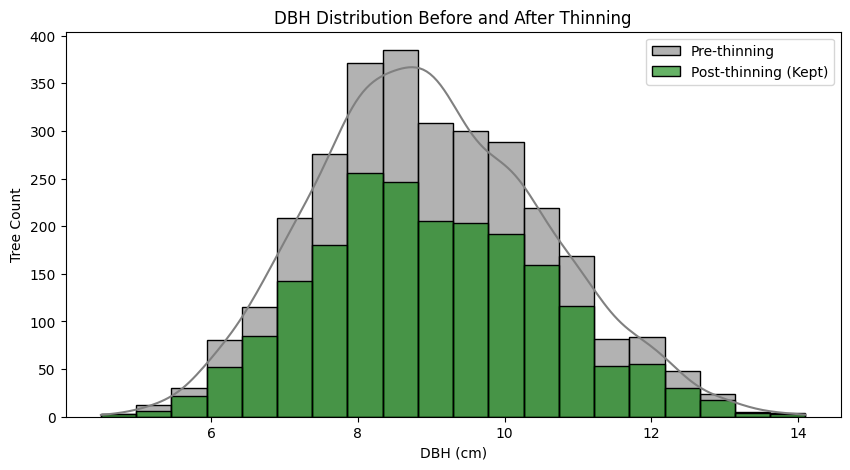

In [194]:
def three_row_thinning(df, start_row=1):
    assert start_row in (1, 2, 3)
    # Initialize thinning decision
    df['thin_decision'] = 'Dead (ignored)'

    alive_mask = df['status'] == 'Alive'
    rows_to_thin = ((df['Row'] - start_row) % 3 == 0)

    # Apply thinning decision only to alive trees
    df.loc[alive_mask & rows_to_thin, 'thin_decision'] = 'Thin'
    df.loc[alive_mask & ~rows_to_thin, 'thin_decision'] = 'Keep'

    return df

def stand_analysis(df_thinned):
    alive = df_thinned[df_thinned['status'] == 'Alive']

    # Pre-thinning stat
    pre_median_dbh = alive['pre_DBH'].median()
    pre_mean_dbh = alive['pre_DBH'].mean()
    pre_total_vol = alive['pre_stem_vol'].sum()

    # Post-thinning stats (kept trees)
    kept = alive[alive['thin_decision'] == 'Keep']
    post_median_dbh = kept['pre_DBH'].median()
    post_mean_dbh = kept['pre_DBH'].mean()
    post_total_vol = kept['pre_stem_vol'].sum()

    # Removed trees stats
    removed = alive[alive['thin_decision'] == 'Thin']
    removed_total_vol = removed['pre_stem_vol'].sum()

    analysis = {
        'Pre-thinning median DBH': round(pre_median_dbh, 2),
        'Pre-thinning mean DBH': round(pre_mean_dbh, 2),
        'Pre-thinning total volume (m³)': round(pre_total_vol, 2),
        'Post-thinning median DBH': round(post_median_dbh, 2),
        'Post-thinning mean DBH': round(post_mean_dbh, 2),
        'Post-thinning total volume (m³)': round(post_total_vol, 2),
        'Volume removed (m³)': round(removed_total_vol, 2),
        '% volume removed': round((removed_total_vol / pre_total_vol) * 100, 2),
        'Trees removed': len(removed),
        'Trees kept': len(kept),
        '% trees removed': round((len(removed) / len(alive)) * 100, 2),
        'Change in median DBH': round(post_median_dbh - pre_median_dbh, 2),
        'Change in mean DBH': round(post_mean_dbh - pre_mean_dbh, 2)
    }
    return analysis

def plot(df_thinned):
    alive = df_thinned[df_thinned['status'] == 'Alive']
    kept = alive[alive['thin_decision'] == 'Keep']
    removed = alive[alive['thin_decision'] == 'Thin']

    plt.figure(figsize=(10, 5))
    sns.histplot(alive['pre_DBH'], bins=20, color='grey', label='Pre-thinning', kde=True, alpha=0.6)
    sns.histplot(kept['pre_DBH'], bins=20, color='green', label='Post-thinning (Kept)', kde=False, alpha=0.6)
    plt.xlabel('DBH (cm)')
    plt.ylabel('Tree Count')
    plt.title('DBH Distribution Before and After Thinning')
    plt.legend()
    plt.show()


df_thinned = three_row_thinning(df, start_row=3)

report = stand_analysis(df_thinned)
print("=== Stand Analysis Report ===")
for k, v in report.items():
    print(f"{k}: {v}")
plot(df_thinned)


In [ ]:
# def plot(db_thinned):
#     alive = db_thinned[db_thinned['status']=='Alive']
#     kept = alive[alive['thin_decision']=='Keep']

#     pre = alive['pre_DBH'].dropna().values
#     post = kept['pre_DBH'].dropna().values

#     pre_mean, pre_median = np.mean(pre), np.median(pre)
#     post_mean, post_median = np.mean(post), np.median(post)

    
#     xmin = min(pre.min(), post.min())
#     xmax = max(pre.max(), post.max())
#     x = np.linspace(xmin, xmax, 400)

    
#     pre_kde = gaussian_kde(pre) if len(pre)>1 else None
#     post_kde = gaussian_kde(post) if len(post)>1 else None

#     plt.figure(figsize=(10,5))

   
#     plt.hist(pre, bins=20, alpha=0.5, label='Pre-thinning', density=True)
#     plt.hist(post, bins=20, alpha=0.5, label='Post-thinning (Kept)', density=True)

    
#     if pre_kde is not None:
#         plt.plot(x, pre_kde(x), label='Pre KDE')
#     if post_kde is not None:
#         plt.plot(x, post_kde(x), label='Post KDE')

#     plt.axvline(pre_mean, linestyle='--', linewidth=1.5, label=f'Pre mean = {pre_mean:.2f}')
#     plt.axvline(pre_median, linestyle=':', linewidth=1.5, label=f'Pre median = {pre_median:.2f}')
#     plt.axvline(post_mean, linestyle='--', linewidth=1.5, label=f'Post mean = {post_mean:.2f}')
#     plt.axvline(post_median, linestyle=':', linewidth=1.5, label=f'Post median = {post_median:.2f}')

#     plt.xlabel('DBH (cm)')
#     plt.ylabel('Density')
#     plt.title('DBH Before vs After Thinning')
#     plt.legend()
#     plt.tight_layout()
#     plt.show()

## Column thinning

=== Stand Analysis Report ===
Pre-thinning median DBH: 8.9
Pre-thinning mean DBH: 8.98
Pre-thinning total volume (m³): 41146.3
Post-thinning median DBH: 8.9
Post-thinning mean DBH: 8.99
Post-thinning total volume (m³): 27272.13
Volume removed (m³): 13874.17
% volume removed: 33.72
Trees removed: 1023
Trees kept: 1994
% trees removed: 33.91
Change in median DBH: 0.0
Change in mean DBH: 0.01


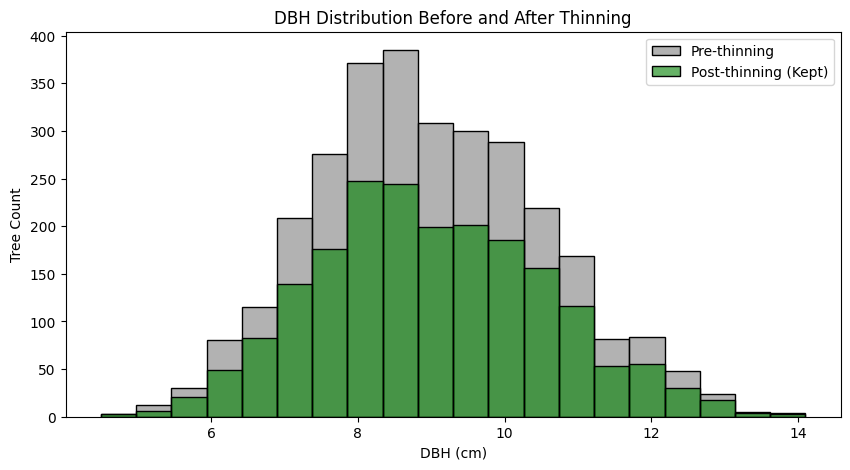

In [180]:
def column_thinning(df, column_select):
    """
    Removes the selected(column_select) tree position across all rows.
    Only applies to Alive trees currently marked 'Keep'.
    """
    df = df.copy()
    alive_keep_mask = (df['status'] == 'Alive') & (df['thin_decision'] == 'Keep')
    column_mask = df['Tree'] == column_select
    df.loc[alive_keep_mask & column_mask, 'thin_decision'] = 'Thin'
    
    return df


df_thinned = column_thinning(df_thinned, column_select=3)

report = stand_analysis(df_thinned)
print("=== Stand Analysis Report ===")
for k, v in report.items():
    print(f"{k}: {v}")

plot(df_thinned)


## Combined thinning

=== Stand Analysis ===
Pre-thinning median DBH: 8.9
Pre-thinning mean DBH: 8.98
Pre-thinning total volume (m³): 41146.3
Post-thinning median DBH: 8.9
Post-thinning mean DBH: 8.99
Post-thinning total volume (m³): 27272.13
Volume removed (m³): 13874.17
% volume removed: 33.72
Trees removed: 1023
Trees kept: 1994
% trees removed: 33.91
Change in median DBH: 0.0
Change in mean DBH: 0.01


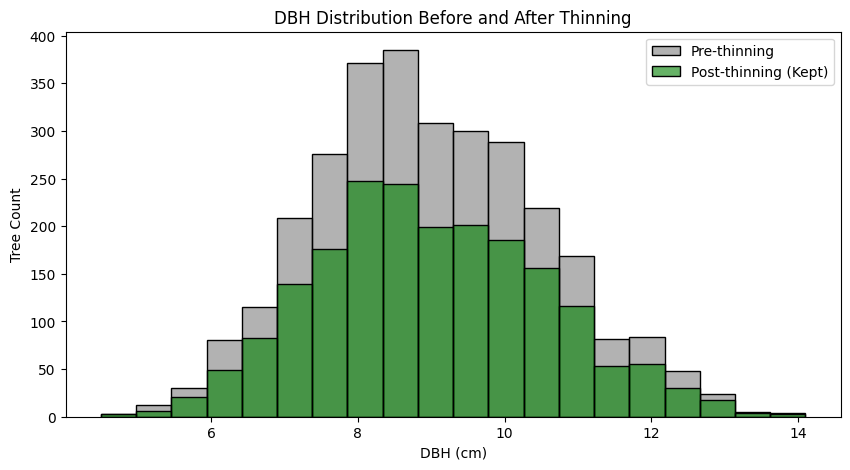

In [192]:
def three_row_thinning(df,start_row=1):
    assert start_row in (1,2,3)
    d=df.copy()
    d['thin_decision']='Dead (ignored)'
    alive=(d['status']=='Alive')
    rows=((d['Row']-start_row)%3==0)
    d.loc[alive & rows,'thin_decision']='Thin'
    d.loc[alive & ~rows,'thin_decision']='Keep'
    return d

def column_thinning_single(df,column_select):
    d=df.copy()
    alive_keep=(d['status']=='Alive')&(d['thin_decision']=='Keep')
    col=(d['Tree']==column_select)
    d.loc[alive_keep & col,'thin_decision']='Thin'
    return d

def combined_thinning(df,start_row=1,column_select=None):
    out=three_row_thinning(df,start_row=start_row)
    if column_select is not None:
        out=column_thinning_single(out,column_select)
    return out

df_rc = combined_thinning(df,start_row=3,column_select=3)


report = stand_analysis(df_rc)
print("=== Stand Analysis ===")
for k,v in report.items(): print(f"{k}: {v}")
plot(df_rc)


## Consolidated table

In [183]:
combos=[(1,1),(2,2),(3,3)]
records=[]
alive_total=int((df['status']=='Alive').sum())

for r,c in combos:
    df_combined = combined_thinning(df,start_row=r,column_select=c)
    rep = stand_analysis(df_combined)

    rep.update({'start_row':r,'column_select':c,'Alive trees pre-thin':alive_total})
    records.append(rep)

summary = pd.DataFrame(records)

# Reorder columns for readability
cols = [
    'start_row','column_select','Alive trees pre-thin',
    'Trees kept','Trees removed','% trees removed',
    'Pre-thinning total volume (m³)','Post-thinning total volume (m³)',
    'Volume removed (m³)','% volume removed',
    'Pre-thinning mean DBH','Post-thinning mean DBH','Change in mean DBH',
    'Pre-thinning median DBH','Post-thinning median DBH','Change in median DBH'
]
summary = summary[cols]

summary = summary.sort_values(['start_row','column_select']).reset_index(drop=True)
summary

,start_row,column_select,Alive trees pre-thin,Trees kept,Trees removed,% trees removed,Pre-thinning total volume (m³),Post-thinning total volume (m³),Volume removed (m³),% volume removed,Pre-thinning mean DBH,Post-thinning mean DBH,Change in mean DBH,Pre-thinning median DBH,Post-thinning median DBH,Change in median DBH
0,1,1,3017,1939,1078,35.73,41146.3,26303.26,14843.04,36.07,8.98,8.96,-0.02,8.9,8.8,-0.1
1,2,2,3017,1980,1037,34.37,41146.3,27080.76,14065.54,34.18,8.98,8.99,0.01,8.9,8.9,0.0
2,3,3,3017,1994,1023,33.91,41146.3,27272.13,13874.17,33.72,8.98,8.99,0.01,8.9,8.9,0.0


## Heatmap of retained volume

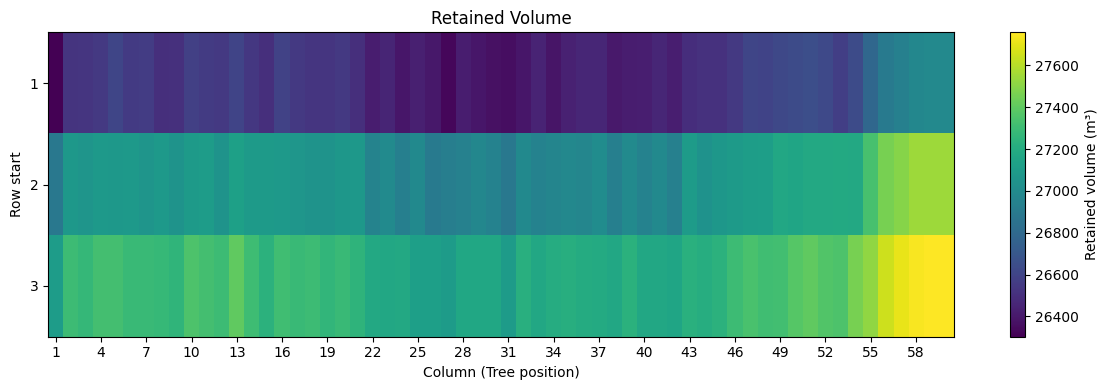

In [184]:
def heatmap(df):

    cols_available = sorted(df['Tree'].dropna().unique().astype(int).tolist())
    results = []

    for r in (1,2,3):
        for c in cols_available:
            d = combined_thinning(df, start_row=r, column_select=int(c))
            rep = stand_analysis(d)
            results.append({
                'start_row': r,
                'column_select': int(c),
                'Retained_volume_m3': rep['Post-thinning total volume (m³)']
            })

    res = pd.DataFrame(results)
    pivot = res.pivot(index='start_row', columns='column_select', values='Retained_volume_m3')

    # --- plot ---
    plt.figure(figsize=(12, 4))
    im = plt.imshow(pivot.values, aspect='auto', origin='upper')
    plt.colorbar(im, label='Retained volume (m³)')
    plt.title('Retained Volume')
    plt.ylabel('Row start')
    plt.yticks(ticks=np.arange(len(pivot.index)), labels=pivot.index)


    xtick_positions = np.arange(pivot.shape[1])
    step = max(1, pivot.shape[1] // 20)
    plt.xticks(ticks=xtick_positions[::step], labels=pivot.columns.astype(int)[::step])
    plt.xlabel('Column (Tree position)')

    plt.tight_layout()
    plt.show()
heatmap(df)

## Spatial Map

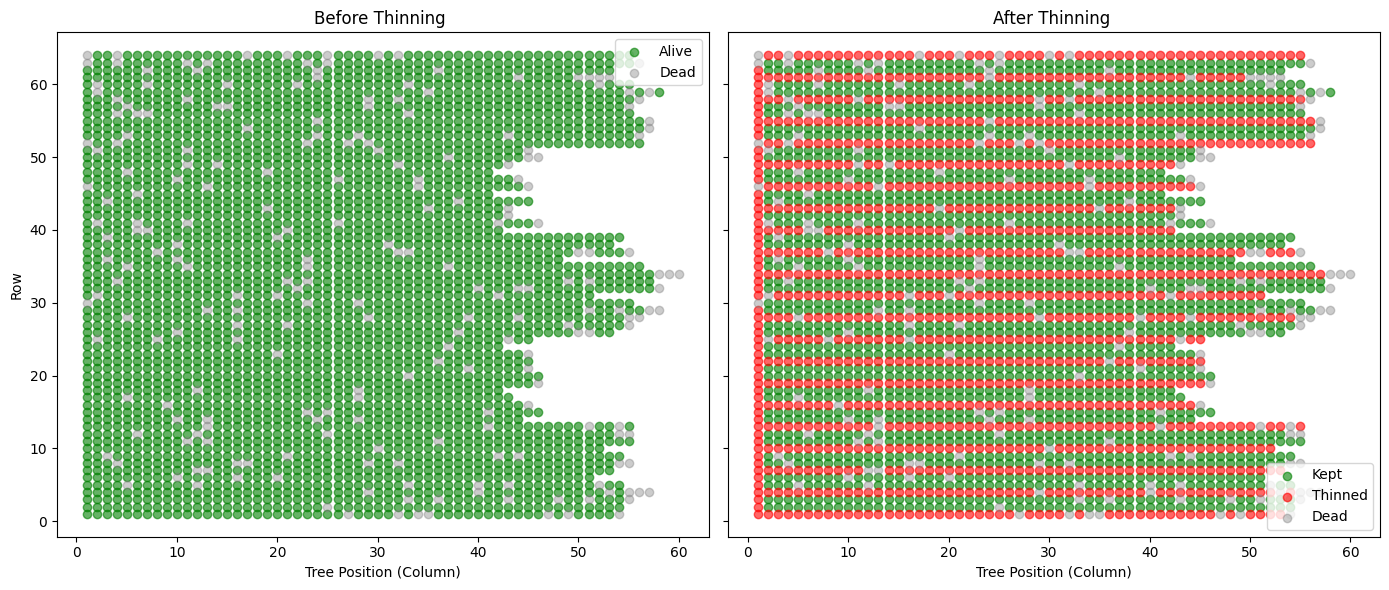

In [191]:
def spatial_map(df_thinned, title_suffix=""):

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    alive = df_thinned[df_thinned['status'] == 'Alive']
    dead = df_thinned[df_thinned['status'] == 'Dead']

    axes[0].scatter(alive['Tree'], alive['Row'], c='green', label='Alive', alpha=0.6)
    axes[0].scatter(dead['Tree'], dead['Row'], c='gray', label='Dead', alpha=0.4)
    axes[0].invert_yaxis()
    axes[0].set_title(f"Before Thinning {title_suffix}")
    axes[0].set_xlabel("Tree Position (Column)")
    axes[0].set_ylabel("Row")
    axes[0].legend()

    kept = alive[alive['thin_decision'] == 'Keep']
    thinned = alive[alive['thin_decision'] == 'Thin']

    axes[1].scatter(kept['Tree'], kept['Row'], c='green', label='Kept', alpha=0.6)
    axes[1].scatter(thinned['Tree'], thinned['Row'], c='red', label='Thinned', alpha=0.6)
    axes[1].scatter(dead['Tree'], dead['Row'], c='gray', label='Dead', alpha=0.4)
    axes[1].invert_yaxis()
    axes[1].set_title(f"After Thinning {title_suffix}")
    axes[1].set_xlabel("Tree Position (Column)")
    axes[1].legend()

    plt.tight_layout()
    plt.show()
spatial_map(df_rc)